In [ ]:
🧭 Lab 4: Time Series, Spatiotemporal Analysis, Geocoding & Routing

🎯 Objectives & Learning Outcomes

In this lab, you will:

Work with time series data using Python (analyzing trends and seasonality).

Explore spatiotemporal datasets that change over both space and time.

Use geocoding to assign locations to addresses.

Perform routing and visualization of geographic movement patterns.

By the end of this lab, you’ll be able to analyze how spatial features evolve over time, geocode real-world locations, and generate optimized routes for mapped data.

In [ ]:
!pip install pandas geopandas folium geopy openrouteservice matplotlib shapely

In [ ]:
import pandas as pd
import geopandas as gpd
import folium
from geopy.geocoders import Nominatim
import openrouteservice
from shapely.geometry import Point
import matplotlib.pyplot as plt
import time

🗓 2. Create a Time Series Dataset

We’ll start by simulating NDVI (vegetation index) data for several city parks across time.

In [ ]:
# Create monthly NDVI data for each park
data = {
    "date": pd.date_range("2023-01-01", periods=12, freq="M"),
    "Central Park": [0.32, 0.35, 0.45, 0.52, 0.65, 0.72, 0.70, 0.68, 0.58, 0.47, 0.40, 0.33],
    "Prospect Park": [0.30, 0.33, 0.42, 0.50, 0.63, 0.69, 0.67, 0.65, 0.55, 0.46, 0.39, 0.31],
    "Bryant Park": [0.28, 0.30, 0.38, 0.45, 0.60, 0.66, 0.63, 0.62, 0.52, 0.43, 0.36, 0.29]
}

df = pd.DataFrame(data)
df.head()


/tmp/ipython-input-947971711.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  "date": pd.date_range("2023-01-01", periods=12, freq="M"),


,date,Central Park,Prospect Park,Bryant Park
0,2023-01-31,0.32,0.30,0.28
1,2023-02-28,0.35,0.33,0.30
2,2023-03-31,0.45,0.42,0.38
3,2023-04-30,0.52,0.50,0.45
4,2023-05-31,0.65,0.63,0.60


Add More Temporal Data

Add two additional parks (or other locations) to your dataset and assign realistic NDVI values.
Then re-run the DataFrame to display your extended dataset.

Your code here ⬇️

In [ ]:
data = {
    "date": pd.date_range("2023-01-01", periods=12, freq="M"),
    "Central Park": [0.32, 0.35, 0.45, 0.52, 0.65, 0.72, 0.70, 0.68, 0.58, 0.47, 0.40, 0.33],
    "Prospect Park": [0.30, 0.33, 0.42, 0.50, 0.63, 0.69, 0.67, 0.65, 0.55, 0.46, 0.39, 0.31],
    "Bryant Park": [0.28, 0.30, 0.38, 0.45, 0.60, 0.66, 0.63, 0.62, 0.52, 0.43, 0.36, 0.29],
    "Marine Park": [0.29, 0.32, 0.41, 0.50, 0.66, 0.71, 0.69, 0.67, 0.57, 0.46, 0.38, 0.30],
    "Astoria Park": [0.27, 0.30, 0.39, 0.47, 0.61, 0.67, 0.65, 0.63, 0.53, 0.44, 0.37, 0.28]
}

df = pd.DataFrame(data)

df


/tmp/ipython-input-2288574605.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  "date": pd.date_range("2023-01-01", periods=12, freq="M"),


,date,Central Park,Prospect Park,Bryant Park,Marine Park,Astoria Park
0,2023-01-31,0.32,0.30,0.28,0.29,0.27
1,2023-02-28,0.35,0.33,0.30,0.32,0.30
2,2023-03-31,0.45,0.42,0.38,0.41,0.39
3,2023-04-30,0.52,0.50,0.45,0.50,0.47
4,2023-05-31,0.65,0.63,0.60,0.66,0.61
5,2023-06-30,0.72,0.69,0.66,0.71,0.67
6,2023-07-31,0.70,0.67,0.63,0.69,0.65
7,2023-08-31,0.68,0.65,0.62,0.67,0.63
8,2023-09-30,0.58,0.55,0.52,0.57,0.53
9,2023-10-31,0.47,0.46,0.43,0.46,0.44


📊 3. Visualize Time Series Trends

We’ll visualize how NDVI changes over time.

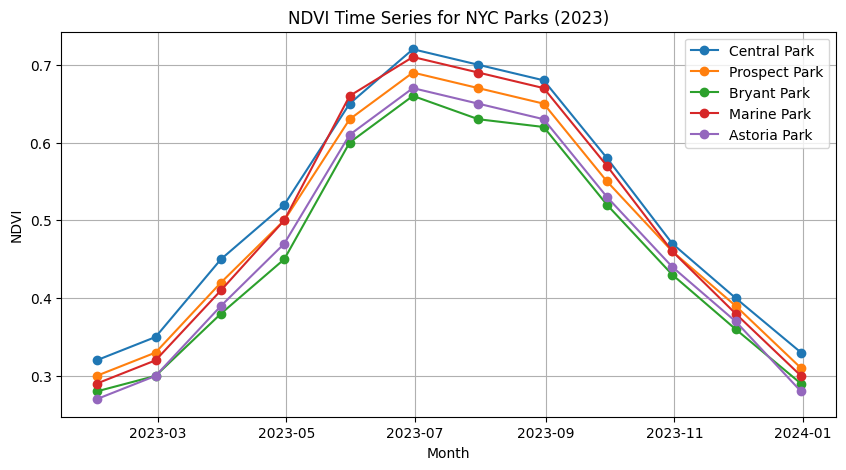

In [ ]:

plt.figure(figsize=(10,5))
for col in df.columns[1:]:
    plt.plot(df["date"], df[col], marker="o", label=col)

plt.title("NDVI Time Series for NYC Parks (2023)")
plt.xlabel("Month")
plt.ylabel("NDVI")
plt.legend()
plt.grid(True)
plt.show()

💡 Your Turn: Highlight Seasonal Peaks

Add vertical lines or shaded regions to show spring and summer growth periods.

Label the plot axes clearly.

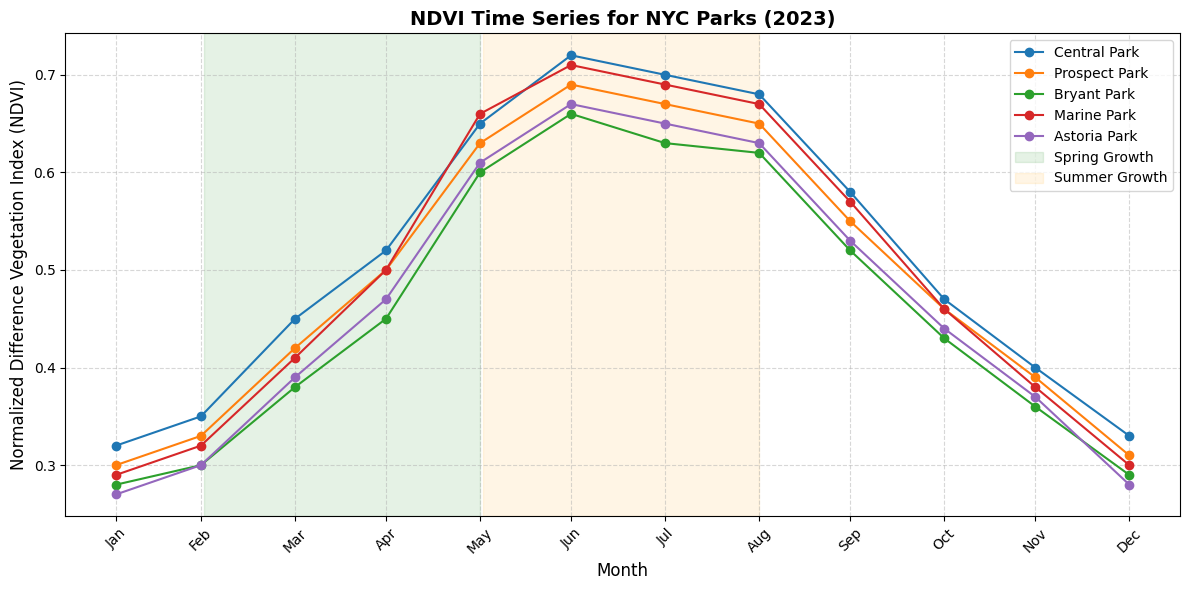

In [ ]:
plt.figure(figsize=(12,6))

for col in df.columns[1:]:
    plt.plot(df["date"], df[col], marker="o", label=col)

plt.axvspan(pd.Timestamp("2023-03-01"), pd.Timestamp("2023-05-31"), color="green", alpha=0.1, label="Spring Growth")
plt.axvspan(pd.Timestamp("2023-06-01"), pd.Timestamp("2023-08-31"), color="orange", alpha=0.1, label="Summer Growth")

plt.title("NDVI Time Series for NYC Parks (2023)", fontsize=14, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Normalized Difference Vegetation Index (NDVI)", fontsize=12)

plt.xticks(df["date"], df["date"].dt.strftime("%b"), rotation=45)

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()

plt.show()

🌍 4. Add Spatial Context: Geocoding the Parks

Let’s geocode each park name to get its latitude and longitude using GeoPy.

In [ ]:
geolocator = Nominatim(user_agent="geo_lab_exercise")

lats, lons = [], []
for place in df.columns[1:]:
    location = geolocator.geocode(f"{place}, New York, NY")
    lats.append(location.latitude)
    lons.append(location.longitude)
    time.sleep(1)

# Create GeoDataFrame
locations = pd.DataFrame({
    "name": df.columns[1:],
    "latitude": lats,
    "longitude": lons
})

gdf = gpd.GeoDataFrame(
    locations,
    geometry=gpd.points_from_xy(locations["longitude"], locations["latitude"]),
    crs="EPSG:4326"
)
gdf


,name,latitude,longitude,geometry
0,Central Park,40.782773,-73.965363,POINT (-73.96536 40.78277)
1,Prospect Park,40.661774,-73.971089,POINT (-73.97109 40.66177)
2,Bryant Park,40.753751,-73.983543,POINT (-73.98354 40.75375)
3,Marine Park,40.605579,-73.934197,POINT (-73.9342 40.60558)
4,Astoria Park,40.778828,-73.922658,POINT (-73.92266 40.77883)


💡 Your Turn: Map the Parks

Use Folium to create an interactive map showing all parks.
Add tooltips with park names and NDVI averages (mean of each column).

In [ ]:
geolocator = Nominatim(user_agent="geo_lab_exercise")

lats, lons = [], []
for place in df.columns[1:]:
    location = geolocator.geocode(f"{place}, New York, NY")
    lats.append(location.latitude)
    lons.append(location.longitude)
    time.sleep(1)

locations = pd.DataFrame({
    "name": df.columns[1:],
    "latitude": lats,
    "longitude": lons
})
gdf = gpd.GeoDataFrame(
    locations,
    geometry=gpd.points_from_xy(locations["longitude"], locations["latitude"]),
    crs="EPSG:4326"
)

ndvi_means = df.mean(numeric_only=True)

nyc_map = folium.Map(location=[40.7128, -74.0060], zoom_start=11, tiles="CartoDB positron")

for idx, row in gdf.iterrows():
    park_name = row["name"]
    avg_ndvi = ndvi_means[park_name]
    tooltip_text = f"<b>{park_name}</b><br>Average NDVI: {avg_ndvi:.2f}"

    folium.Marker(
        location=[row["latitude"], row["longitude"]],
        tooltip=tooltip_text,
        icon=folium.Icon(color="green", icon="tree", prefix="fa")
    ).add_to(nyc_map)

nyc_map

🗺 5. Spatiotemporal Visualization (Advanced Option)

Plot NDVI trends by location — linking time series with space.

In [ ]:
avg_ndvi = df.mean(numeric_only=True)
gdf["avg_ndvi"] = avg_ndvi.values

m = folium.Map(location=[40.75, -73.97], zoom_start=12)
for _, row in gdf.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=row["avg_ndvi"] * 30,  # scale NDVI to size
        color="green",
        fill=True,
        fill_opacity=0.6,
        popup=f"{row['name']}: NDVI={row['avg_ndvi']:.2f}"
    ).add_to(m)
m


💡 Your Turn: Spatiotemporal Change

Simulate a “year-over-year” NDVI increase for each park and visualize it on the map with a color gradient or size change.

In [ ]:
gdf["avg_ndvi_2023"] = df.mean(numeric_only=True).values
growth_rate = np.random.uniform(0.02, 0.10, size=len(gdf))
gdf["avg_ndvi_2024"] = gdf["avg_ndvi_2023"] * (1 + growth_rate)
gdf["percent_increase"] = (gdf["avg_ndvi_2024"] - gdf["avg_ndvi_2023"]) / gdf["avg_ndvi_2023"] * 100

m = folium.Map(location=[40.73, -73.95], zoom_start=11, tiles="CartoDB positron")

for _, row in gdf.iterrows():
    radius = row["avg_ndvi_2024"] * 40
    growth = row["percent_increase"]

    if growth < 4:
        color = "#a1d99b"
    elif growth < 7:
        color = "#31a354"
    else:
        color = "#006d2c"

    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=radius,
        color=color,
        fill=True,
        fill_opacity=0.7,
    ).add_to(m)

m

🚗 6. Routing Between Parks

Let’s plan a route visiting all the parks using OpenRouteService (or fallback to OSRM).

In [ ]:
import folium
import requests

# Example coordinates (longitude, latitude)
coords = [
    (-73.968285, 40.785091),  # Central Park
    (-73.985428, 40.748817),  # Empire State Building
    (-73.985130, 40.758896)   # Times Square
]

# Convert coords to OSRM format
coord_str = ";".join([f"{lon},{lat}" for lon, lat in coords])

# Build OSRM API URL
url = f"http://router.project-osrm.org/route/v1/foot/{coord_str}?overview=full&geometries=geojson"

# Send request
response = requests.get(url)
data = response.json()

# Extract route geometry
route = data['routes'][0]['geometry']

# Plot on map
m = folium.Map(location=[40.758, -73.985], zoom_start=13)
folium.GeoJson(route, name="Walking Route", color="purple").add_to(m)

# Add markers for reference
for lat, lon in [(lat, lon) for lon, lat in coords]:
    folium.Marker(location=[lat, lon]).add_to(m)

m



💡 Your Turn: Modify the Route

Change the profile to "driving-car" or "cycling-regular".

Add a legend or color code different route types.

In [ ]:
import folium
import requests
from geopy.geocoders import Nominatim
import time

parks = ["Central Park, New York, NY",
         "Prospect Park, New York, NY",
         "Bryant Park, New York, NY",
         "Marine Park, New York, NY",
         "Astoria Park, New York, NY"]

geolocator = Nominatim(user_agent="geo_lab_exercise")
coords = []
for park in parks:
    loc = geolocator.geocode(park)
    coords.append((loc.longitude, loc.latitude))
    time.sleep(1)

coord_str = ";".join([f"{lon},{lat}" for lon, lat in coords])

profiles = {
    "foot": {"url": "foot", "color": "purple", "label": "Walking Route"},
    "cycling": {"url": "cycling", "color": "blue", "label": "Cycling Route"},
    "driving": {"url": "driving", "color": "red", "label": "Driving Route"}
}

m = folium.Map(location=[40.70, -73.95], zoom_start=11, tiles="CartoDB positron")

for key, profile in profiles.items():
    url = f"http://router.project-osrm.org/route/v1/{profile['url']}/{coord_str}?overview=full&geometries=geojson"
    response = requests.get(url)
    data = response.json()

    if "routes" in data and len(data["routes"]) > 0:
        route = data["routes"][0]["geometry"]
        folium.GeoJson(
            route,
            name=profile["label"],
            style_function=lambda x, color=profile["color"]: {"color": color, "weight": 4, "opacity": 0.8}
        ).add_to(m)

for i, (lon, lat) in enumerate(coords):
    folium.Marker(
        location=[lat, lon],
        tooltip=parks[i].replace(", New York, NY", ""),
        icon=folium.Icon(color="green", icon="tree", prefix="fa")
    ).add_to(m)

legend_html = """
<div style="
    position: fixed;
    bottom: 30px; left: 30px; width: 170px; height: 130px;
    background-color: white;
    border:2px solid grey; z-index:9999; font-size:14px;
    box-shadow: 2px 2px 5px rgba(0,0,0,0.3);
    padding: 10px;">
<b>Route Legend</b><br>
<span style="color:purple;">&#9679;</span> Walking Route<br>
<span style="color:blue;">&#9679;</span> Cycling Route<br>
<span style="color:red;">&#9679;</span> Driving Route
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

folium.LayerControl().add_to(m)

m

💭 7. Reflection Questions

Answer these in Colab “+ Text” cells:

**What trends or seasonal patterns did you observe in your time series data?**
    *In the beginning months of the year, vegetation is low because of the winter season. In the spring months, we see an increase in vegetation and the peak is during the summer months, once we reach the fall months, the vegetation decreases until you reach November and December, where it is winter again and too cold for vegetation.*
**How does connecting temporal data with spatial location enhance your analysis?**
     *We are able to see where different changes are happening and when they are happening. We can see which parks change at which times and keep track of it that way.*
**What limitations or challenges did you encounter while geocoding or routing?**
     *A problem that I had with routing is that all three routes are exactly the same, so I had to add a way to only see one route at a time in order to see the different routes, although they are all the same.*
**How might this type of spatiotemporal workflow support real-world urban or environmental decisions?**
   *It helps to see what changes are being made and where. It lets planners or other officials see what changes are coming and when they can be expected at different places throughout the city to plan for different stages of the environment throughout the year.*

🧾 8. Wrapping Up!

✅ Submission Checklist

✔️ All “Your Turn” code cells completed and commented
✔️ Three or more reflection answers written in text cells
✔️ At least one Folium map created (with NDVI visualization and route)
✔️ Notebook renamed as:
Lab4_TimeSeries_Spatiotemporal_Geocoding_Routing_YourName.ipynb

Share your link in your submission.